# Diabetes Prediction using Logistic Regression

This project applies a Logistic Regression classifier to the Diabetes Dataset. The workflow includes exploratory data analysis, data preprocessing, feature scaling, model training, evaluation using multiple metrics, and interpretation of feature importance.

## Import Libraries

In [69]:
import numpy as np 
import pandas as pd
import seaborn as sns
from sklearn import metrics
import matplotlib.pyplot as plt 
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

## Load Dataset

In [70]:
Data = pd.read_csv("diabetes.csv")
Data

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


**Feature Descriptions**

**Pregnancies:** Number of times pregnant.

**Glucose:** Plasma glucose concentration measured 2 hours after an oral glucose tolerance test.

**BloodPressure:** Diastolic blood pressure (mm Hg).

**SkinThickness:** Triceps skinfold thickness (mm).

**Insulin:** 2-hour serum insulin (μU/mL).

**BMI:** Body Mass Index (BMI), calculated as weight (kg) divided by height squared (m²).

**DiabetesPedigreeFunction:** A function that estimates the likelihood of diabetes based on family history.

**Age:** Age in years.

**Outcome:** Diabetes diagnosis, where **0 = No** and **1 = Yes**.

## Feature Selection

In [71]:
x = Data.iloc[:, :-1]
y = Data.iloc[:, -1]

## Feature Description

In [72]:
feature_names = x.columns.tolist()
print(feature_names)

['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']


## Dataset Overview & Exploratory Data Analysis (EDA)

In [73]:
sns.set_theme(style="whitegrid", palette="muted")
styled = Data.head(10).style.background_gradient(cmap='Blues').format(precision=2) 
styled

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.60,0.63,50,1
1,1,85,66,29,0,26.60,0.35,31,0
2,8,183,64,0,0,23.30,0.67,32,1
3,1,89,66,23,94,28.10,0.17,21,0
4,0,137,40,35,168,43.10,2.29,33,1
5,5,116,74,0,0,25.60,0.20,30,0
6,3,78,50,32,88,31.00,0.25,26,1
7,10,115,0,0,0,35.30,0.13,29,0
8,2,197,70,45,543,30.50,0.16,53,1
9,8,125,96,0,0,0.00,0.23,54,1


## Data Preprocessing

In [74]:
Data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [75]:
Data.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [76]:
Data.isna().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [77]:
Data

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


## Feature Distributions

In [78]:
feature_names

['Pregnancies',
 'Glucose',
 'BloodPressure',
 'SkinThickness',
 'Insulin',
 'BMI',
 'DiabetesPedigreeFunction',
 'Age']

In [79]:
for feature in x.columns:
    print(feature, x[feature].nunique())

Pregnancies 17
Glucose 136
BloodPressure 47
SkinThickness 51
Insulin 186
BMI 248
DiabetesPedigreeFunction 517
Age 52


In [80]:
discrete_features = ["Pregnancies"]

continuous_features = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
    "DiabetesPedigreeFunction",
    "Age"
]

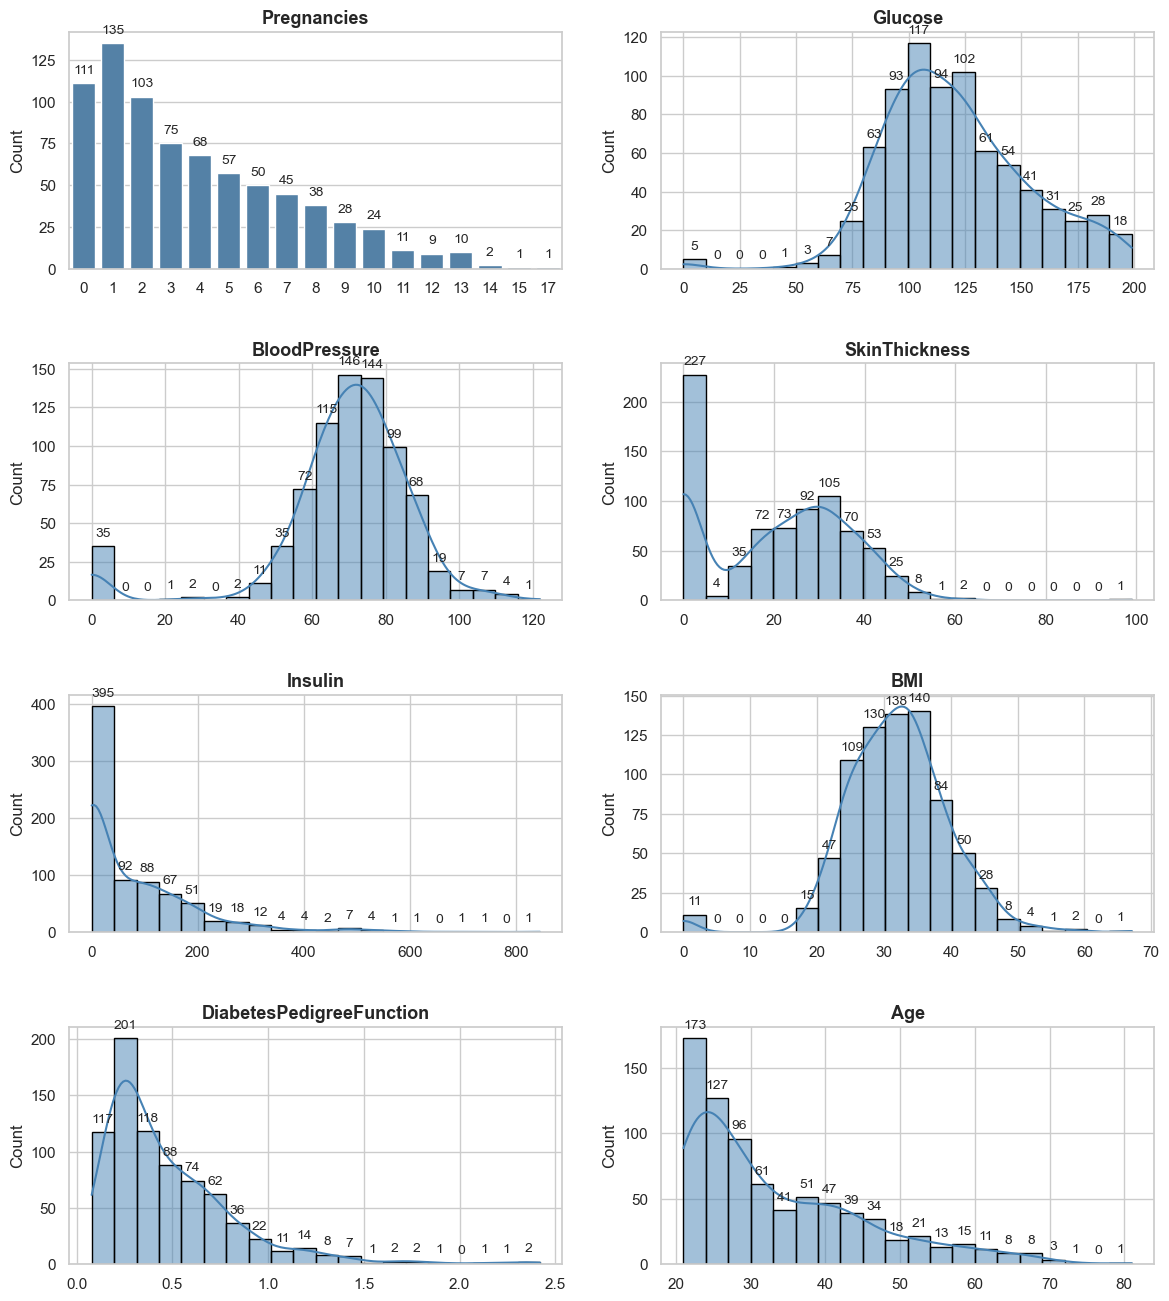

In [81]:
# Style
sns.set_style("whitegrid")

# Number of features
n_features = len(x.columns)

# Layout
n_cols = 2
n_rows = (n_features + n_cols - 1) // n_cols

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(14, 4 * n_rows),
    # constrained_layout=True
)

axes = axes.flatten()

for i, feature in enumerate(x.columns):

    if feature in discrete_features:

        sns.countplot(
            x=x[feature],
            ax=axes[i],
            color="steelblue"
        )

    else:

        sns.histplot(
            x[feature],
            bins=20,
            kde=True,
            ax=axes[i],
            color="steelblue",
            edgecolor="black"
        )



    for container in axes[i].containers:
        axes[i].bar_label(
            container,
            fmt='%d',
            padding=5,
            fontsize=10)


    axes[i].set_title(feature, fontsize=13, fontweight="bold")
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Count")   

    plt.subplots_adjust(
    hspace=0.4,
    wspace=0.2
    )
      

C:\Users\user\AppData\Local\Temp\ipykernel_16816\2379778744.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax= sns.countplot(


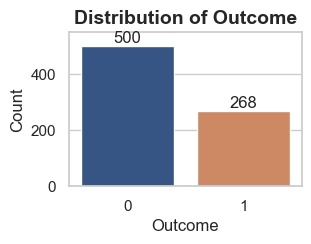

In [82]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(3, 2))

ax= sns.countplot(
    x="Outcome",
    data=Data,
    # color="steelblue"
    palette=["#295191", "#DD8452"]
)

for container in ax.containers:
    ax.bar_label(container)

ax.set_ylim(0, max(Data["Outcome"].value_counts()) + 50)    

plt.title("Distribution of Outcome", fontsize=14, fontweight="bold")
plt.xlabel("Outcome")
plt.ylabel("Count")

plt.show()

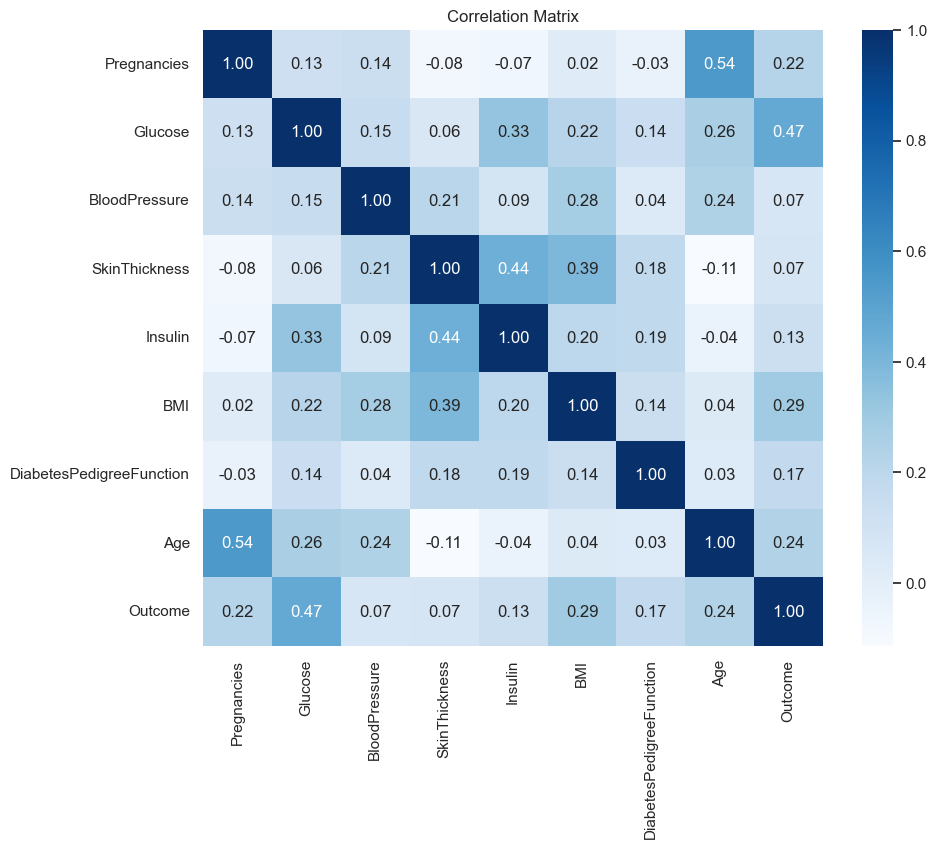

In [83]:
plt.figure(figsize=(10,8))

sns.heatmap(
    Data.corr(),
    annot=True,
    cmap="Blues",
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()

C:\Users\user\AppData\Local\Temp\ipykernel_16816\2711715468.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\user\AppData\Local\Temp\ipykernel_16816\2711715468.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\user\AppData\Local\Temp\ipykernel_16816\2711715468.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\user\AppData\Local\Temp\ipykernel_16816\2711715468.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` 

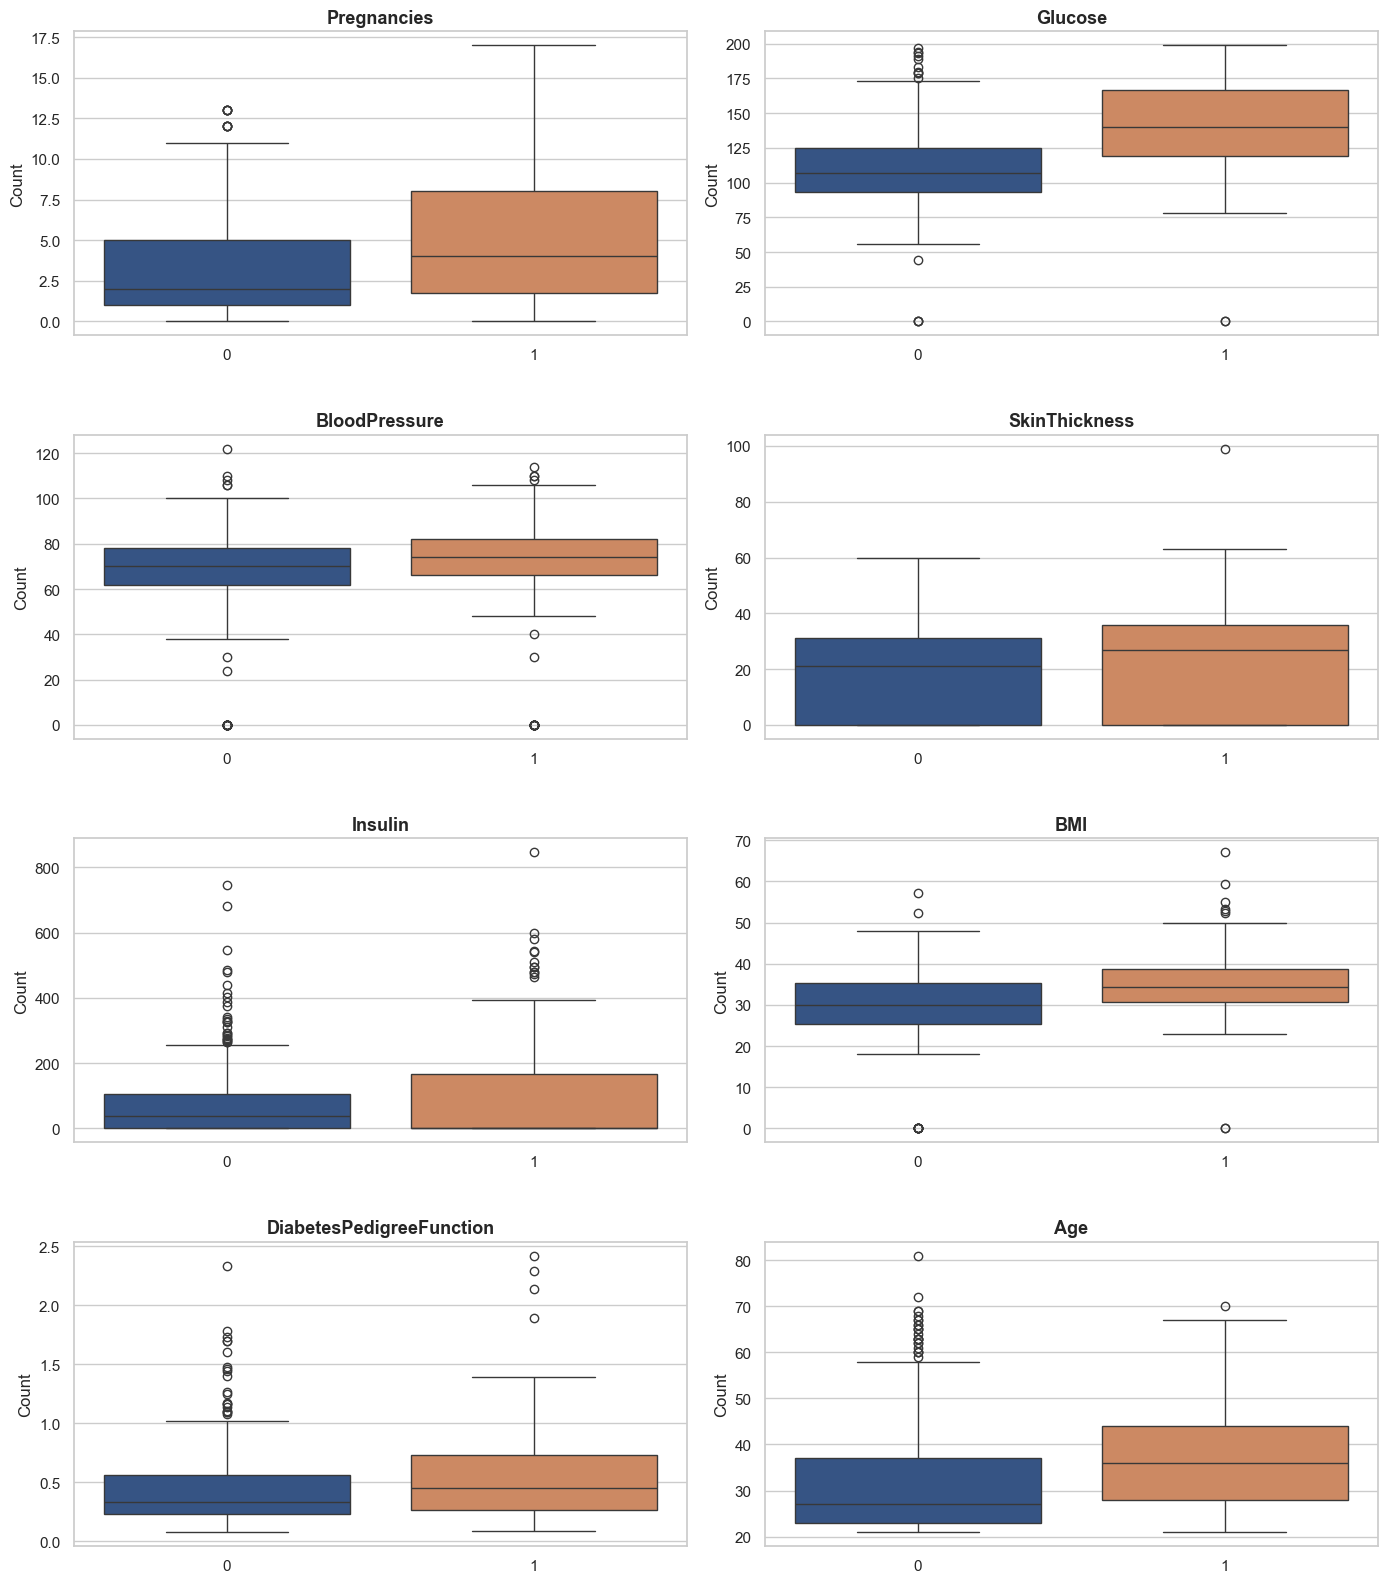

In [84]:
# Style
sns.set_style("whitegrid")

# Number of features
n_features = len(x.columns)

# Layout
n_cols = 2
n_rows = (n_features + n_cols - 1) // n_cols

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(14, 4 * n_rows),
    # constrained_layout=True
)

axes = axes.flatten()

for i, feature in enumerate(x.columns):

    sns.boxplot(
        x="Outcome",
        y=feature,
        data=Data,
        ax=axes[i],
        palette=["#295191", "#DD8452"]
    )


    axes[i].set_title(feature, fontsize=13, fontweight="bold")
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Count")   

    plt.subplots_adjust(
    hspace=0.4,
    wspace=0.2
    )


for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])    

plt.tight_layout(h_pad=3)
plt.show()      

In [85]:
for col in feature_names:
    print(f"{col}: {(Data[col] == 0).sum()}")

Pregnancies: 111
Glucose: 5
BloodPressure: 35
SkinThickness: 227
Insulin: 374
BMI: 11
DiabetesPedigreeFunction: 0
Age: 0


In [86]:
columns = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]

Data[columns] = Data[columns].replace(0, np.nan)

In [87]:
for col in columns:
    Data[col].fillna(Data[col].median(), inplace=True)

C:\Users\user\AppData\Local\Temp\ipykernel_16816\3261164458.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  Data[col].fillna(Data[col].median(), inplace=True)


In [88]:
Data[columns].isnull().sum()

Glucose          0
BloodPressure    0
SkinThickness    0
Insulin          0
BMI              0
dtype: int64

In [89]:
X = Data.drop("Outcome", axis=1)
y = Data["Outcome"]

In [90]:
X_train, X_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [91]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Train Logistic Regression Model

In [92]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(solver='liblinear')

model.fit(X_train, y_train)

LogisticRegression(solver='liblinear')

In [93]:
y_pred = model.predict(X_test)

## Model Evaluation

In [94]:
model.classes_

array([0, 1], dtype=int64)

In [95]:
model.intercept_

array([-0.86479607])

In [96]:
model.coef_

array([[ 0.37228961,  1.14178562, -0.19709167,  0.06634522, -0.12721099,
         0.71126582,  0.25542331,  0.18306415]])

In [97]:
print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.7142857142857143

Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.82      0.79       100
           1       0.61      0.52      0.56        54

    accuracy                           0.71       154
   macro avg       0.68      0.67      0.67       154
weighted avg       0.71      0.71      0.71       154



In [98]:
y_prob = model.predict_proba(X_test)

In [99]:
print(y_prob[:5])

[[0.38157125 0.61842875]
 [0.88610334 0.11389666]
 [0.72543755 0.27456245]
 [0.71101518 0.28898482]
 [0.99540941 0.00459059]]


In [100]:
# The ROC curve uses only the predicted probabilities
# of the positive class (diabetes).
y_prob = model.predict_proba(X_test)[:, 1] 
y_prob

array([0.61842875, 0.11389666, 0.27456245, 0.28898482, 0.00459059,
       0.19095233, 0.46994271, 0.91735064, 0.10454208, 0.78171278,
       0.29832499, 0.63725799, 0.1294035 , 0.10038822, 0.31071124,
       0.35274666, 0.70508805, 0.09651937, 0.78347015, 0.23732476,
       0.16831372, 0.65771444, 0.18570965, 0.92667072, 0.5293934 ,
       0.01913788, 0.59035282, 0.05852155, 0.33720555, 0.04346329,
       0.05096669, 0.05346009, 0.46370993, 0.55900118, 0.85220501,
       0.13710352, 0.33031787, 0.07648471, 0.74178809, 0.58743824,
       0.30725773, 0.10646517, 0.09925588, 0.29945413, 0.15930382,
       0.41901934, 0.17610819, 0.12418841, 0.58631852, 0.52374293,
       0.65315334, 0.82008954, 0.37693686, 0.07822074, 0.51386193,
       0.34548399, 0.77531067, 0.241451  , 0.74742187, 0.14869113,
       0.76984659, 0.22119798, 0.00673448, 0.86848924, 0.04441037,
       0.15352715, 0.93706254, 0.02263929, 0.27912295, 0.64476563,
       0.19752151, 0.10117795, 0.32991914, 0.47639484, 0.04392

In [101]:
model.predict(X_test)

array([1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1,
       0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0,
       1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1,
       0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0],
      dtype=int64)

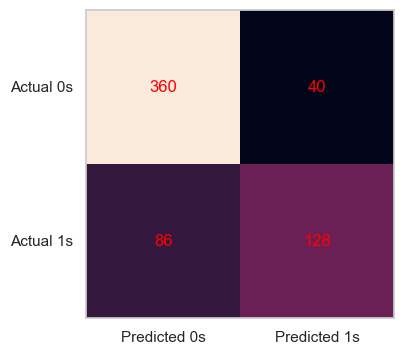

In [102]:
cm_train= confusion_matrix(y_train,model.predict(X_train))

fig, ax = plt.subplots(figsize=(4,4))
ax.imshow(cm_train)
ax.grid(False)
ax.xaxis.set(ticks= (0,1), ticklabels =('Predicted 0s', 'Predicted 1s'))
ax.yaxis.set(ticks=(0,1), ticklabels = ('Actual 0s', 'Actual 1s'))
ax.set_ylim(1.5, -0.5)
for i in range(2):
    for j in range (2):
        ax.text(j,i,cm_train[i,j], ha= 'center', va='center', color= 'red')

plt.show()

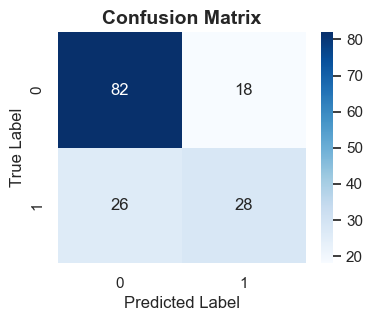

In [103]:
cm_test = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(4,3))

sns.heatmap(
    cm_test,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix", fontsize=14, fontweight="bold")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

## ROC Curve and AUC

TPR: Percentage of actual diabetic patients correctly classified.

FPR: Percentage of healthy individuals incorrectly classified as diabetic.

In [104]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
print(len(thresholds))

54


**AUC (Area Under the ROC Curve)**

Measures the model's ability to distinguish between diabetic and non-diabetic patients.
A higher AUC indicates better overall classification performance.
An AUC closer to 1.0 represents a better classifier, while an AUC of 0.5 indicates random guessing.

In [105]:
auc = roc_auc_score(y_test, y_prob)

print(auc)

0.8233333333333333


**Interpretation:**

AUC = 0.823 indicates that the model has a good ability
to distinguish between diabetic and non-diabetic patients.

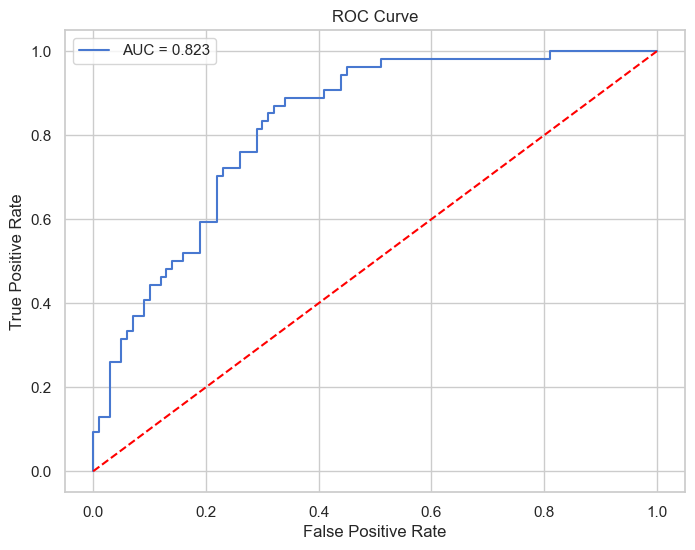

In [106]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")

plt.plot([0,1], [0,1], "--", color="red")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

**Interpretation**

- A curve close to the diagonal line indicates poor performance.
- A curve well above the diagonal line indicates good performance.
- The closer the curve is to the upper-left corner, the better the classifier.

# Extract feature coefficients

In [107]:
# Extract feature coefficients
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
})

coefficients

,Feature,Coefficient
0,Pregnancies,0.372290
1,Glucose,1.141786
2,BloodPressure,-0.197092
3,SkinThickness,0.066345
4,Insulin,-0.127211
5,BMI,0.711266
6,DiabetesPedigreeFunction,0.255423
7,Age,0.183064


In [108]:
coefficients["Absolute Coefficient"] = coefficients["Coefficient"].abs()

coefficients = coefficients.sort_values(
    by="Absolute Coefficient",
    ascending=False
).reset_index(drop=True)
coefficients

,Feature,Coefficient,Absolute Coefficient
0,Glucose,1.141786,1.141786
1,BMI,0.711266,0.711266
2,Pregnancies,0.372290,0.372290
3,DiabetesPedigreeFunction,0.255423,0.255423
4,BloodPressure,-0.197092,0.197092
5,Age,0.183064,0.183064
6,Insulin,-0.127211,0.127211
7,SkinThickness,0.066345,0.066345


**Feature Importance Interpretation**

The coefficient values indicate the influence of each feature on the Logistic Regression model. Glucose has the highest absolute coefficient, making it the most influential predictor of diabetes. BMI and Pregnancies also contribute significantly to the prediction. In contrast, SkinThickness has the smallest impact. Negative coefficients (e.g., BloodPressure and Insulin) indicate an inverse relationship with the predicted probability of diabetes.

The coefficient values are comparable because all features were standardized before training the model.

## Conclusion

In this project, a Logistic Regression model was developed to predict diabetes using the Diabetes dataset.

The model achieved a good classification performance with an AUC score of 0.823, demonstrating its ability to distinguish between diabetic and non-diabetic patients. Feature coefficient analysis showed that Glucose was the most influential predictor, followed by BMI and Pregnancies.

Overall, Logistic Regression provides a simple, interpretable, and effective baseline model for diabetes prediction.

Future Work: More advanced models such as Random Forest, XGBoost, or Support Vector Machine (SVM) could be explored and compared with Logistic Regression to improve predictive performance.